# Experiment: Stage1 Latent Clustering

Objective:
- Train only TriShift `stage1` and extract `z_mu` latent space.
- Use the stage1 latent space for clustering, UMAP, and label alignment analysis.
- Support two modes: `pbmc_celltype` and `trishift_condition`.

Notes:
- This notebook does not run `stage23`.
- PBMC data source is fixed to `src/data/pbmc/train_pbmc.h5ad`.
- No cross-celltype holdout is done here; this notebook only handles clustering.
- PBMC is read directly from the processed h5ad, matching the scPRAM tutorial style; no extra normalize/log1p/HVG preprocessing is applied here.
- Clustering prefers Leiden. If `python-igraph` is missing in the notebook environment, the helper falls back to `KMeans` automatically and still writes UMAP + metrics.
- UMAP plotting defaults are aligned to scGPT integration examples: `neighbors(use_rep=...)`, `min_dist=0.3`, compact `(4, 4)` figures, and `dpi=300` export.


In [1]:
from __future__ import annotations

from pathlib import Path
from IPython.display import Image, display

import pandas as pd

repo_root = Path.cwd()
if not (repo_root / "scripts").exists() and (repo_root.parent / "scripts").exists():
    repo_root = repo_root.parent

import sys
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

from scripts.trishift.analysis.stage1_latent_clustering import run_stage1_latent_clustering

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)


## Plan

- `pbmc_celltype`: cluster stage1 latent by PBMC `cell_type` and `condition`.
- `trishift_condition`: cluster stage1 latent by perturbation `condition` on a TriShift dataset.
- Default stage1 pool is `train_all_cells`, closer to scGPT-style cell embedding analysis.
- Outputs are written to `artifacts/stage1_latent_clustering/...`.


## Metrics guide

This notebook now reports both the original local metrics and scGPT/scIB-style names for the same quantities.

- `ari_leiden_vs_label` and `ARI_cluster/label`: the same Adjusted Rand Index between notebook-generated clusters and the target label. Higher is better. `1.0` means cluster assignments align almost perfectly; near `0` means close to random agreement.
- `nmi_leiden_vs_label` and `NMI_cluster/label`: the same Normalized Mutual Information between clusters and the target label. Higher is better. Compared with ARI, it is less sensitive to label permutation and easier to read when cluster counts differ.
- `silhouette_label` and `ASW_label`: the same silhouette score computed on the stage1 latent vectors using the target label itself, not the predicted cluster. Higher is better. Positive values mean same-label cells stay closer together than different-label cells; around `0` means weak separation; negative means labels are mixed.
- `avg_bio`: scGPT-style summary metric, defined as `mean(NMI_cluster/label, ARI_cluster/label, ASW_label)`. Higher is better. Use it as a compact biological-conservation score, but still inspect the three components separately.
- `n_unique_clusters` vs `n_unique_labels`: quick sanity check. If clusters are far more than labels, the partition may be over-fragmented; if far fewer, the latent may be under-separating biological groups.
- `cluster_method`: `leiden` if the environment has `igraph`; otherwise `kmeans_fallback`. Compare runs only when the clustering method is the same.

How to read the results:
- `pbmc_celltype`: prioritize `label_cell_type`, especially `avg_bio`, `ARI_cluster/label`, `NMI_cluster/label`, and `ASW_label`. `label_condition` is secondary and usually weaker because this notebook is not a perturbation predictor.
- PBMC DEG weighting, when enabled, only applies to `stimulated` cells and uses `by_cell_type` DEG sets.
- `trishift_condition`: prioritize `label_condition`. `label_ctrl_pert` only tells you whether stage1 separates control from perturbed cells at a coarse level.
- UMAP is for qualitative structure inspection. Trust the numeric metrics first, then use UMAP to understand failure modes such as label overlap, fragmentation, or batch-like stripes.


In [ ]:
# Core config
mode = "pbmc_celltype"              # "pbmc_celltype" or "trishift_condition"
dataset_name = "pbmc"               # pbmc / adamson / dixit / norman / replogle_k562_essential / replogle_rpe1_essential
split_id = 1
stage1_pool_mode = "train_all_cells"  # "train_all_cells" or "ctrl_only"
random_seed = 24

# Stage1 training
stage1_epochs = 100         # None -> helper default
stage1_z_dim = 128             # None -> defaults.yaml model.stage1.z_dim
stage1_batch_size = 64           # None -> defaults.yaml
stage1_lr = 0.0005             # None -> defaults.yaml
stage1_beta = 0.9            # None -> defaults.yaml
stage1_deg_weight = 5          # None -> defaults.yaml; >1 upweights DE genes in stage1 recon loss
pbmc_deg_mode = "by_cell_type"    # PBMC-only; currently only supports by_cell_type

# Latent + clustering
l2_normalize_latent = False
neighbors_k = None                # None -> scGPT-style scanpy default
leiden_resolution = 1.0
umap_min_dist = 0.3
reuse_z_mu_cache = False
save_dpi = 300
cluster_figsize = (4, 4)
label_figsize = (4, 4)
point_size_cluster = None        # None -> use scanpy/scGPT default
point_size_label = None          # None -> use scanpy/scGPT default
preview_width = 720

# PBMC-only config
pbmc_path = repo_root / "src" / "data" / "pbmc" / "train_pbmc.h5ad"
pbmc_train_frac = 0.9


In [3]:
run_kwargs = dict(
    mode=mode,
    dataset_name=dataset_name,
    split_id=split_id,
    stage1_pool_mode=stage1_pool_mode,
    random_seed=random_seed,
    stage1_epochs=stage1_epochs,
    stage1_z_dim=stage1_z_dim,
    stage1_batch_size=stage1_batch_size,
    stage1_lr=stage1_lr,
    stage1_beta=stage1_beta,
    stage1_deg_weight=stage1_deg_weight,
    pbmc_path=pbmc_path,
    pbmc_train_frac=pbmc_train_frac,
    pbmc_deg_mode=pbmc_deg_mode,
    l2_normalize_latent=l2_normalize_latent,
    neighbors_k=neighbors_k,
    leiden_resolution=leiden_resolution,
    umap_min_dist=umap_min_dist,
    reuse_z_mu_cache=reuse_z_mu_cache,
    save_dpi=save_dpi,
    cluster_figsize=cluster_figsize,
    label_figsize=label_figsize,
    point_size_cluster=point_size_cluster,
    point_size_label=point_size_label,
)

result = run_stage1_latent_clustering(**run_kwargs)
result.metrics_df


d:\conda_envs\scouter\lib\site-packages\anndata\compat\__init__.py:371: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(
d:\conda_envs\scouter\lib\site-packages\anndata\compat\__init__.py:371: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  warn(


[embd] embedding index ready: key=embd_index


d:\conda_envs\scouter\lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


[stage1] start vae training: epochs=100, batch_size=64
[stage1] deg_weight=3.0, deg_weight_active=true


E:\CODE\trishift\src\trishift\TriShift.py:1242: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
stage1 1/100:   0%|          | 0/238 [00:00<?, ?it/s]E:\CODE\trishift\src\trishift\TriShift.py:1256: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
E:\CODE\trishift\src\trishift\TriShift.py:1299: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


[stage1] early stop at epoch 38
[stage1] done vae training; vae frozen
[stage1] start encoding z_mu: batch_size=64, key=z_mu


E:\CODE\trishift\src\trishift\TriShift.py:1376: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


[stage1] cached z_mu: shape=(16893, 32)


d:\conda_envs\scouter\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,label_key,n_obs,n_unique_labels,n_unique_clusters,ari_leiden_vs_label,nmi_leiden_vs_label,silhouette_label,ARI_cluster/label,NMI_cluster/label,ASW_label,avg_bio
0,label_cell_type,16893,7,7,0.449801,0.586950,0.067859,0.449801,0.586950,0.067859,0.368203
1,label_condition,16893,2,7,0.281296,0.388487,0.136444,0.281296,0.388487,0.136444,0.268742
2,label_ctrl_pert,16893,2,7,0.281296,0.388487,0.136444,0.281296,0.388487,0.136444,0.268742


In [4]:
print(f"Output dir: {result.out_dir}")
print(f"Latent h5ad: {result.latent_h5ad_path}")
print(f"z_mu cache: {result.z_mu_path}")
print(f"Metrics csv: {result.metrics_csv_path}")
print(f"Train logs: {result.train_logs_path}")
print(f"Cluster method: {result.metadata['cluster_method']}")
print()
print("Figure files:")
for key, path in sorted(result.figure_paths.items()):
    print(f"- {key}: {path}")


Output dir: E:\CODE\trishift\artifacts\stage1_latent_clustering\pbmc_celltype\pbmc\split1\train_all_cells_seed24
Latent h5ad: E:\CODE\trishift\artifacts\stage1_latent_clustering\pbmc_celltype\pbmc\split1\train_all_cells_seed24\latent_with_clusters.h5ad
z_mu cache: E:\CODE\trishift\artifacts\stage1_latent_clustering\pbmc_celltype\pbmc\split1\train_all_cells_seed24\z_mu.npz
Metrics csv: E:\CODE\trishift\artifacts\stage1_latent_clustering\pbmc_celltype\pbmc\split1\train_all_cells_seed24\cluster_metrics.csv
Train logs: E:\CODE\trishift\artifacts\stage1_latent_clustering\pbmc_celltype\pbmc\split1\train_all_cells_seed24\stage1_train_logs.json
Cluster method: kmeans_fallback

Figure files:
- cluster_vs_label_cell_type: E:\CODE\trishift\artifacts\stage1_latent_clustering\pbmc_celltype\pbmc\split1\train_all_cells_seed24\cluster_vs_label_cell_type.png
- cluster_vs_label_condition: E:\CODE\trishift\artifacts\stage1_latent_clustering\pbmc_celltype\pbmc\split1\train_all_cells_seed24\cluster_vs_labe

In [5]:
result.metrics_df


,label_key,n_obs,n_unique_labels,n_unique_clusters,ari_leiden_vs_label,nmi_leiden_vs_label,silhouette_label,ARI_cluster/label,NMI_cluster/label,ASW_label,avg_bio
0,label_cell_type,16893,7,7,0.449801,0.586950,0.067859,0.449801,0.586950,0.067859,0.368203
1,label_condition,16893,2,7,0.281296,0.388487,0.136444,0.281296,0.388487,0.136444,0.268742
2,label_ctrl_pert,16893,2,7,0.281296,0.388487,0.136444,0.281296,0.388487,0.136444,0.268742


umap_by_cluster


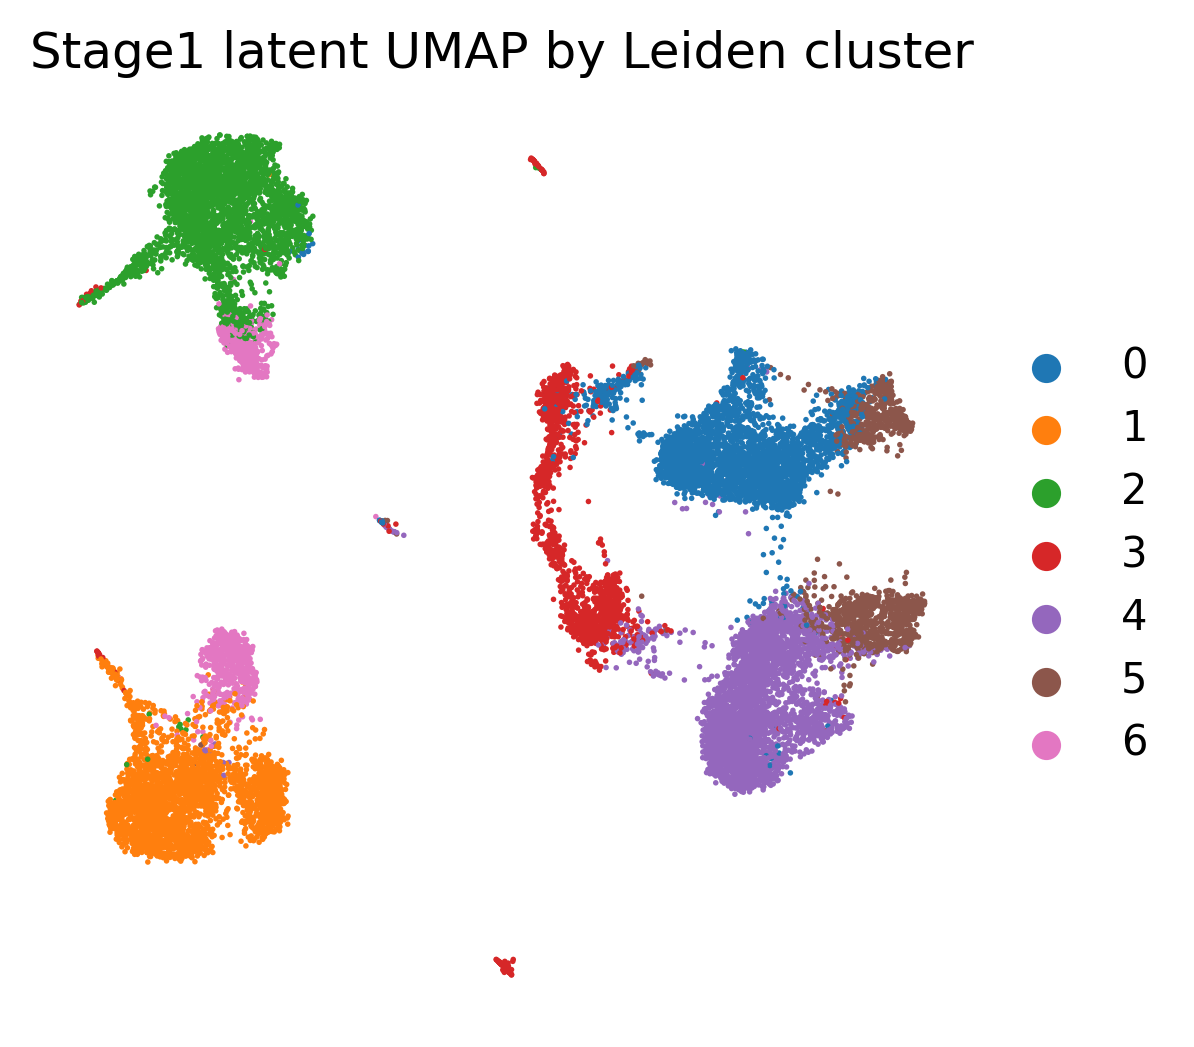

umap_by_label_cell_type


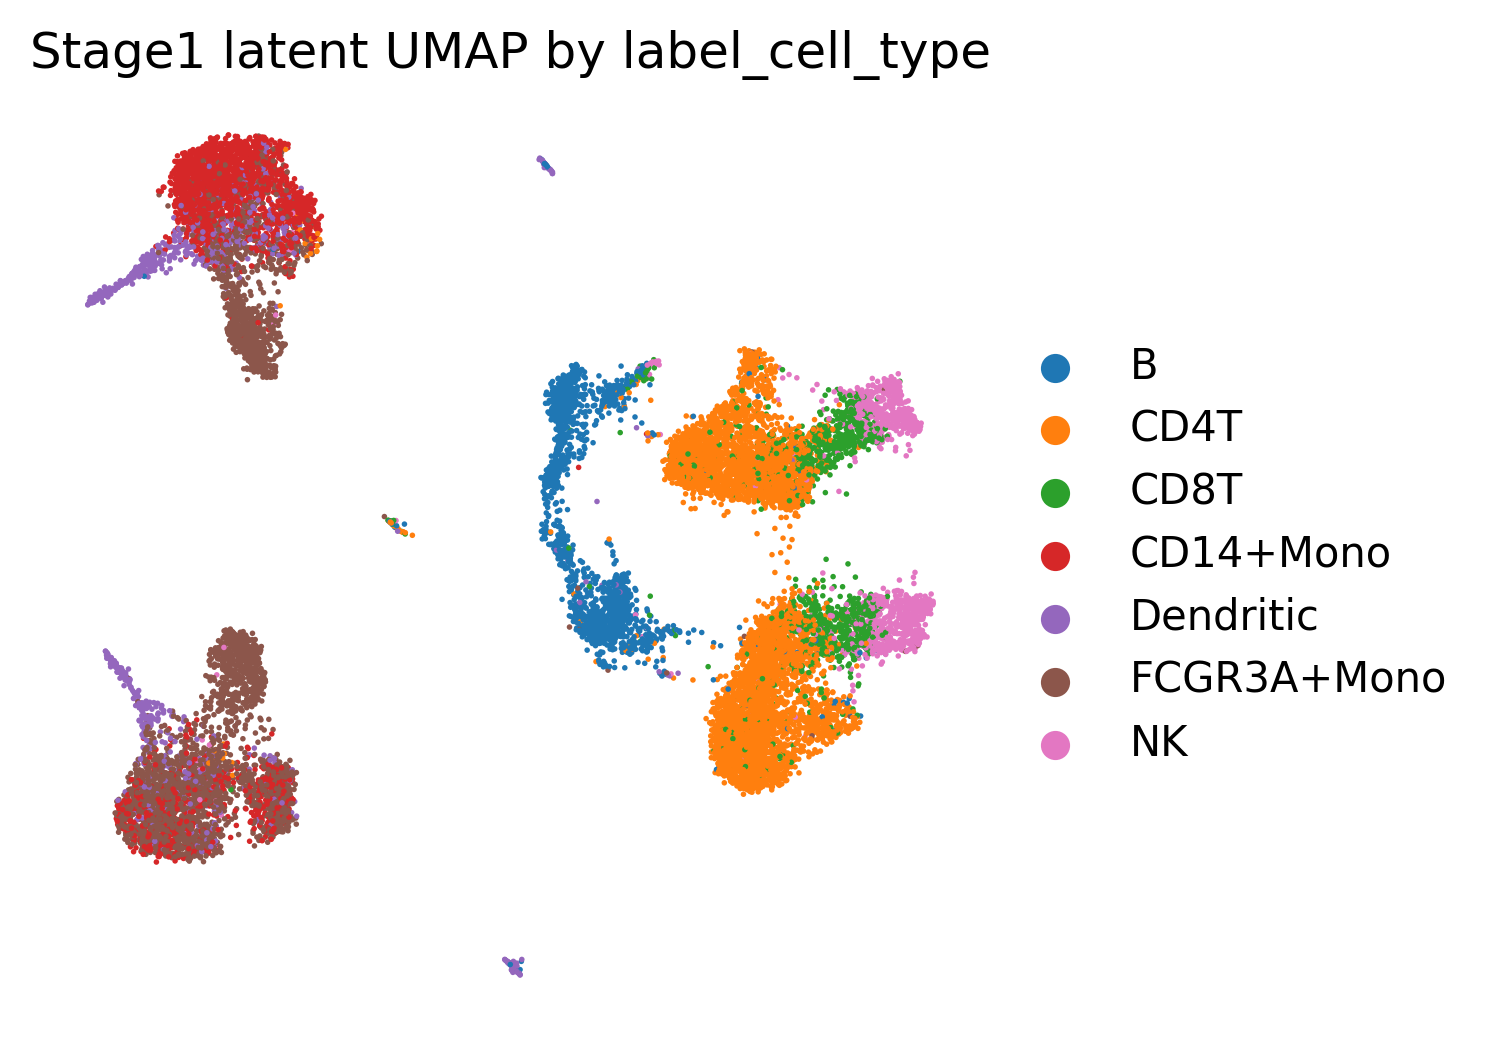

umap_by_label_condition


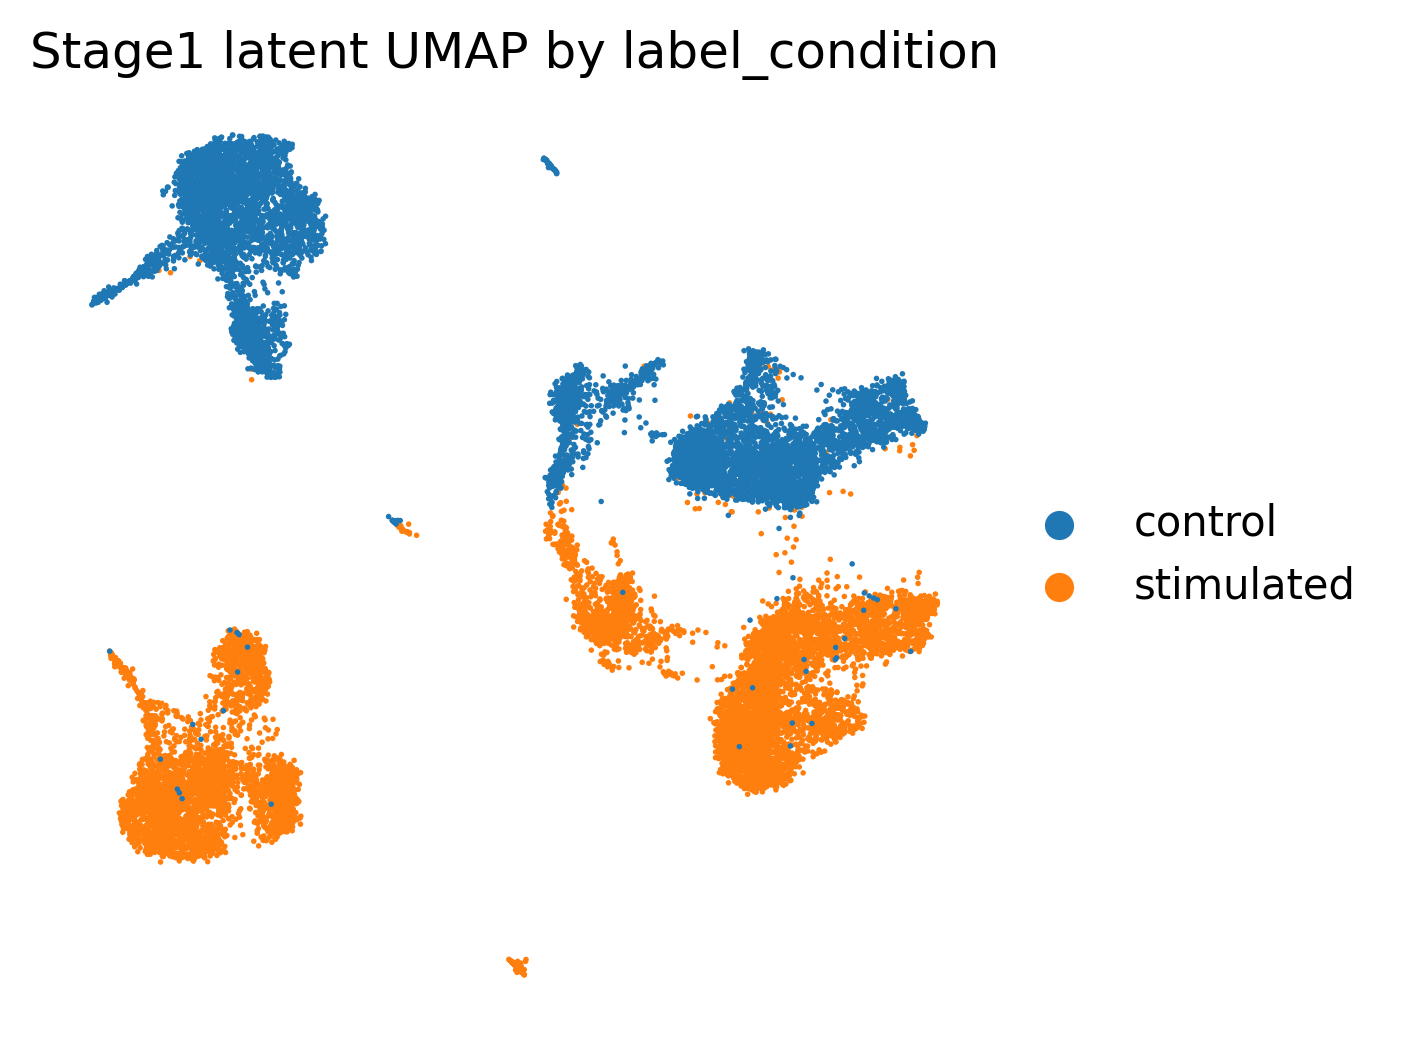

umap_by_label_ctrl_pert


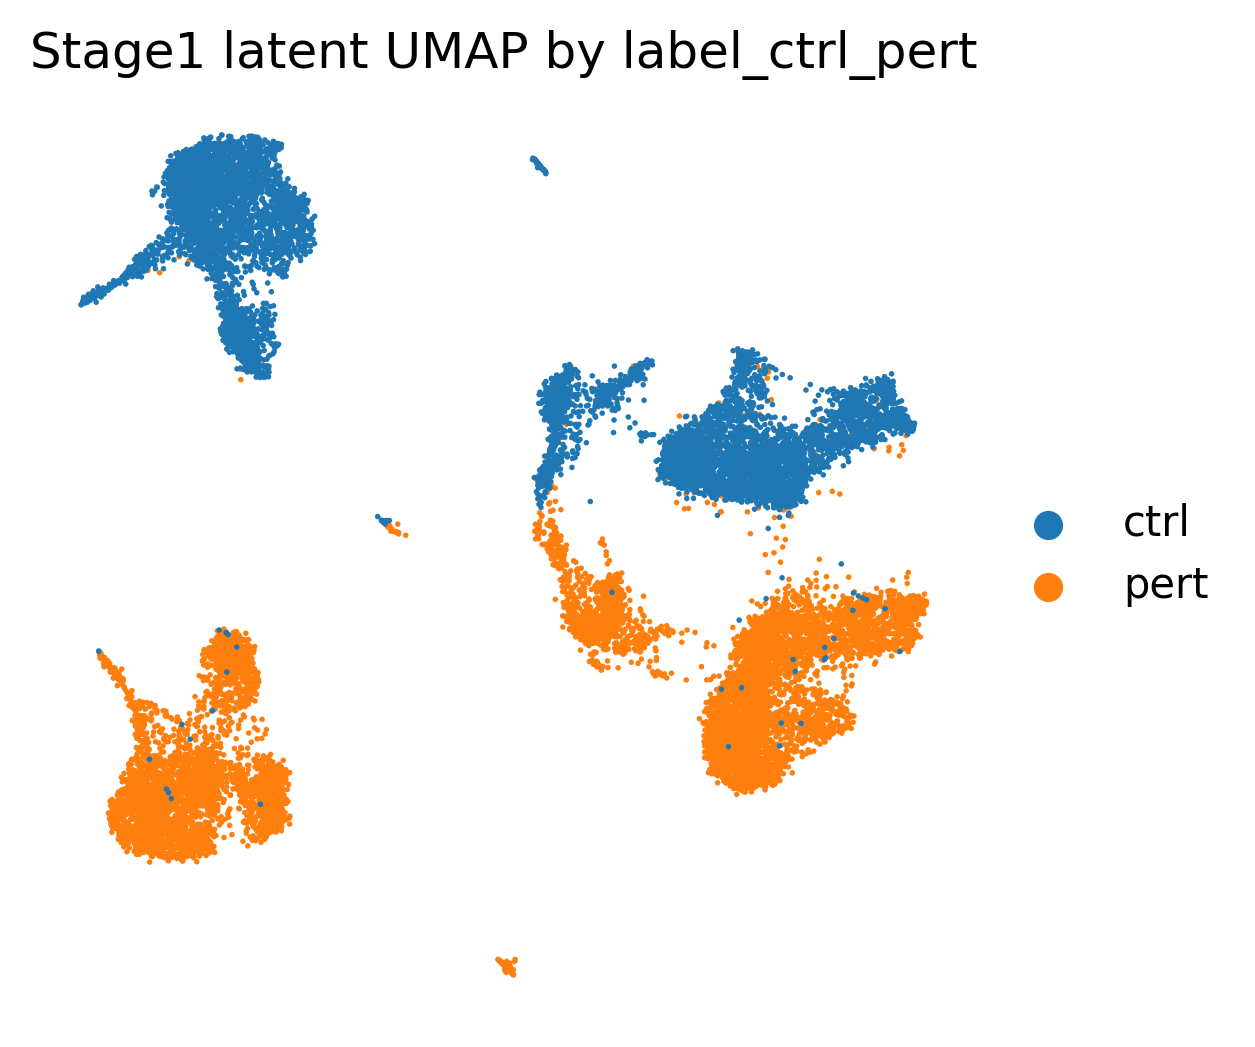

In [6]:
for key in ["umap_by_cluster", *[k for k in result.figure_paths if k.startswith("umap_by_") and k != "umap_by_cluster"]]:
    path = result.figure_paths.get(key)
    if path:
        print(key)
        display(Image(filename=path, width=preview_width))
